# ECGR 4106/5106 — Homework 1

CNN architecture comparison on CIFAR-10 (AlexNet / VGG-11 / ResNet-11 / ResNet-18).
Seed 42, 45k/5k/10k split, SGD (momentum 0.9, lr 0.01), batch size 128.

In [ ]:
import os, json, time, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('WARNING: no GPU detected — switch the Colab runtime to T4 before training!')

Device: cuda
GPU: Tesla T4


In [ ]:
if 'SAVE_DIR' not in globals():
    SAVE_DIR = './hw1_results'
os.makedirs(SAVE_DIR, exist_ok=True)
print('Results will be saved to:', SAVE_DIR)

Results will be saved to: ./hw1_results


## Data

45k train / 5k val / 10k test. Crop + flip augmentation on the training set only.

In [ ]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])
eval_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

root = './data'
full_train_aug  = torchvision.datasets.CIFAR10(root, train=True,  download=True, transform=train_tf)
full_train_eval = torchvision.datasets.CIFAR10(root, train=True,  download=True, transform=eval_tf)
test_set        = torchvision.datasets.CIFAR10(root, train=False, download=True, transform=eval_tf)

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(50_000, generator=g).tolist()
train_idx, val_idx = perm[:45_000], perm[45_000:]

train_set = Subset(full_train_aug,  train_idx)   # augmented
val_set   = Subset(full_train_eval, val_idx)     # NOT augmented

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=False)
val_loader   = DataLoader(val_set,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

CLASSES = full_train_aug.classes
print(f'train {len(train_set)} | val {len(val_set)} | test {len(test_set)}')
print('classes:', CLASSES)

100%|██████████| 170M/170M [00:03<00:00, 49.0MB/s]


train 45000 | val 5000 | test 10000
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Training and evaluation utilities

In [ ]:
RESULTS = {}

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss_sum += criterion(out, y).item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return loss_sum / n, correct / n

def train_model(model, name, epochs=30, lr=0.01, momentum=0.9, use_scheduler=False):
    if name in RESULTS:
        print(f'[{name}] already completed — skipping (delete from RESULTS to retrain).')
        return None

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
                 if use_scheduler else None)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'epoch_time': []}
    for epoch in range(epochs):
        model.train()
        t0, running, n = time.time(), 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            running += loss.item() * x.size(0)
            n += x.size(0)
        if scheduler is not None:
            scheduler.step()

        train_loss = running / n
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        dt = time.time() - t0
        for k, v in zip(history, (train_loss, val_loss, val_acc, dt)):
            history[k].append(v)
        print(f'[{name}] epoch {epoch+1:3d}/{epochs} | train {train_loss:.4f} | '
              f'val {val_loss:.4f} | val acc {val_acc*100:.2f}% | {dt:.1f}s')

    _, test_acc = evaluate(model, test_loader, criterion)
    RESULTS[name] = {
        'history': history,
        'test_acc': test_acc,
        'params': count_params(model),
        'avg_epoch_time': float(np.mean(history['epoch_time'])),
        'hyperparams': {'optimizer': 'SGD', 'lr': lr, 'momentum': momentum,
                        'batch_size': BATCH_SIZE, 'epochs': epochs,
                        'scheduler': 'CosineAnnealingLR' if use_scheduler else 'none',
                        'loss': 'CrossEntropyLoss', 'seed': SEED},
    }
    with open(os.path.join(SAVE_DIR, f'{name}.json'), 'w') as f:
        json.dump(RESULTS[name], f)
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, f'{name}.pt'))
    print(f'[{name}] DONE — test accuracy {test_acc*100:.2f}% | '
          f'{count_params(model):,} params | {np.mean(history["epoch_time"]):.1f}s/epoch')
    return model

def reload_results():
    for fn in sorted(os.listdir(SAVE_DIR)):
        if fn.endswith('.json'):
            with open(os.path.join(SAVE_DIR, fn)) as f:
                RESULTS[fn[:-5]] = json.load(f)
    print('Restored runs:', list(RESULTS.keys()))

def load_weights(model, name):
    model.load_state_dict(torch.load(os.path.join(SAVE_DIR, f'{name}.pt'), map_location=device))
    return model.to(device)

def plot_history(names, title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for name in names:
        h = RESULTS[name]['history']
        ep = range(1, len(h['train_loss']) + 1)
        axes[0].plot(ep, h['train_loss'], label=name)
        axes[1].plot(ep, h['val_loss'], label=name)
        axes[2].plot(ep, [a * 100 for a in h['val_acc']], label=name)
    for ax, ylab in zip(axes, ['Training loss', 'Validation loss', 'Validation accuracy (%)']):
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylab); ax.grid(alpha=0.3); ax.legend()
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

def show_confusion(model, name):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in test_loader:
            preds.append(model(x.to(device)).argmax(1).cpu())
            targets.append(y)
    cm = confusion_matrix(torch.cat(targets), torch.cat(preds))
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f'Confusion matrix — {name} (test set)')
    plt.tight_layout(); plt.show()

def show_first_layer_filters(model, name):
    w = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            w = m.weight.data.clone().cpu()
            break
    w = (w - w.min()) / (w.max() - w.min())
    n, cols = w.shape[0], 8
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.1, rows * 1.1))
    for i, ax in enumerate(np.array(axes).flatten()):
        ax.axis('off')
        if i < n:
            ax.imshow(w[i].permute(1, 2, 0).numpy())
    fig.suptitle(f'First-layer filters — {name}')
    plt.tight_layout(); plt.show()

def comparison_table(names):
    rows = []
    for n in names:
        r = RESULTS[n]
        h = r['history']
        conv = next((i + 1 for i, a in enumerate(h['val_acc']) if a >= 0.70), None)
        rows.append({'model': n,
                     'params': f"{r['params']:,}",
                     'test acc (%)': round(r['test_acc'] * 100, 2),
                     'best val acc (%)': round(max(h['val_acc']) * 100, 2),
                     's / epoch': round(r['avg_epoch_time'], 1),
                     'epochs to 70% val acc': conv if conv else '—',
                     'final train-val gap (loss)': round(h['val_loss'][-1] - h['train_loss'][-1], 3)})
    return pd.DataFrame(rows)

---
# Problem 1 — Modified AlexNet

In [ ]:
class ModifiedAlexNet(nn.Module):
    def __init__(self, num_classes=10, dropout_p=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                          # 32 -> 16
            nn.Conv2d(64, 192, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                          # 16 -> 8
            nn.Conv2d(192, 384, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                          # 8 -> 4
        )
        def maybe_drop():
            return [nn.Dropout(dropout_p)] if dropout_p > 0 else []
        self.classifier = nn.Sequential(
            nn.Flatten(),
            *maybe_drop(), nn.Linear(256 * 4 * 4, 1024), nn.ReLU(inplace=True),
            *maybe_drop(), nn.Linear(1024, 512), nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

alexnet = ModifiedAlexNet()
n_params = count_params(alexnet)
print(f'Modified AlexNet parameters: {n_params:,}')
print(f'Original AlexNet parameters: ~61,100,000')
print(f'Reduction factor: {61_100_000 / n_params:.1f}x')

Modified AlexNet parameters: 6,976,842
Original AlexNet parameters: ~61,100,000
Reduction factor: 8.8x


In [ ]:
!pip -q install torchsummary
from torchsummary import summary
summary(alexnet.to(device), (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 192, 16, 16]         110,784
              ReLU-5          [-1, 192, 16, 16]               0
         MaxPool2d-6            [-1, 192, 8, 8]               0
            Conv2d-7            [-1, 384, 8, 8]         663,936
              ReLU-8            [-1, 384, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         884,992
             ReLU-10            [-1, 256, 8, 8]               0
           Conv2d-11            [-1, 256, 8, 8]         590,080
             ReLU-12            [-1, 256, 8, 8]               0
        MaxPool2d-13            [-1, 256, 4, 4]               0
          Flatten-14                 [-

In [ ]:
alexnet = ModifiedAlexNet()
alexnet_trained = train_model(alexnet, 'alexnet_baseline', epochs=30)

[alexnet_baseline] epoch   1/30 | train 2.2071 | val 1.9157 | val acc 26.32% | 19.4s
[alexnet_baseline] epoch   2/30 | train 1.7865 | val 1.5839 | val acc 41.36% | 18.8s
[alexnet_baseline] epoch   3/30 | train 1.5458 | val 1.3808 | val acc 49.24% | 20.8s
[alexnet_baseline] epoch   4/30 | train 1.3663 | val 1.3453 | val acc 49.46% | 18.3s
[alexnet_baseline] epoch   5/30 | train 1.2367 | val 1.0833 | val acc 61.28% | 19.3s
[alexnet_baseline] epoch   6/30 | train 1.0979 | val 1.0147 | val acc 62.66% | 18.4s
[alexnet_baseline] epoch   7/30 | train 0.9756 | val 0.9683 | val acc 64.96% | 19.0s
[alexnet_baseline] epoch   8/30 | train 0.8868 | val 0.7896 | val acc 71.80% | 18.1s
[alexnet_baseline] epoch   9/30 | train 0.8073 | val 0.7243 | val acc 74.38% | 18.6s
[alexnet_baseline] epoch  10/30 | train 0.7452 | val 0.6637 | val acc 76.64% | 19.1s
[alexnet_baseline] epoch  11/30 | train 0.6918 | val 0.6729 | val acc 76.68% | 18.2s
[alexnet_baseline] epoch  12/30 | train 0.6444 | val 0.6274 | val

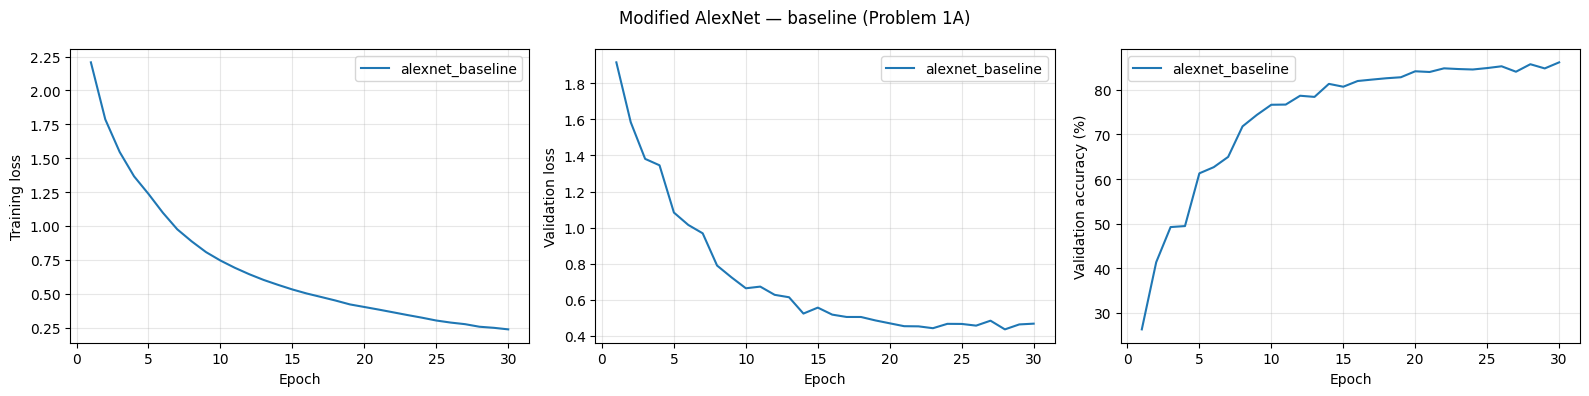

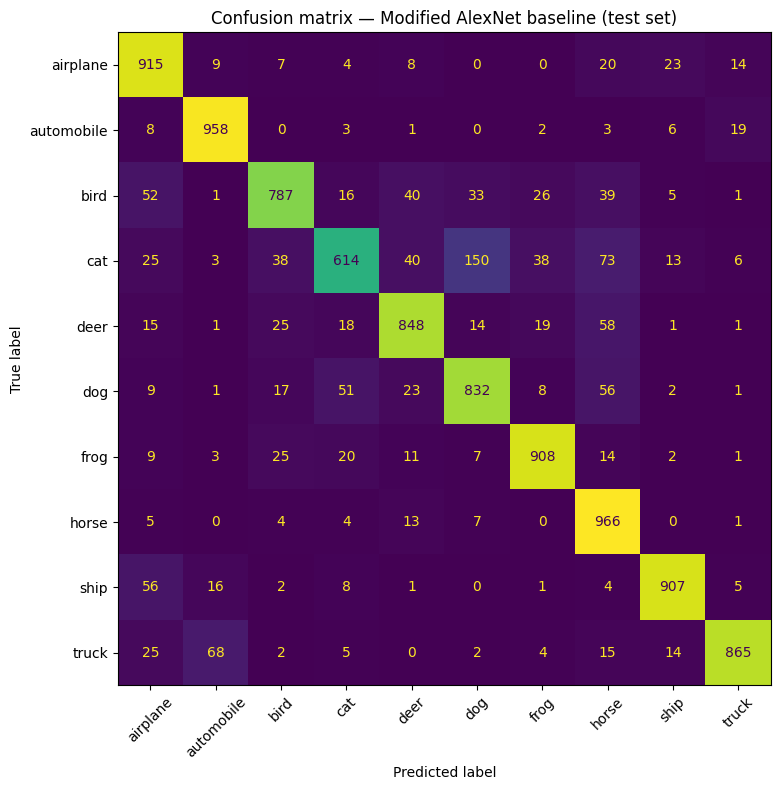

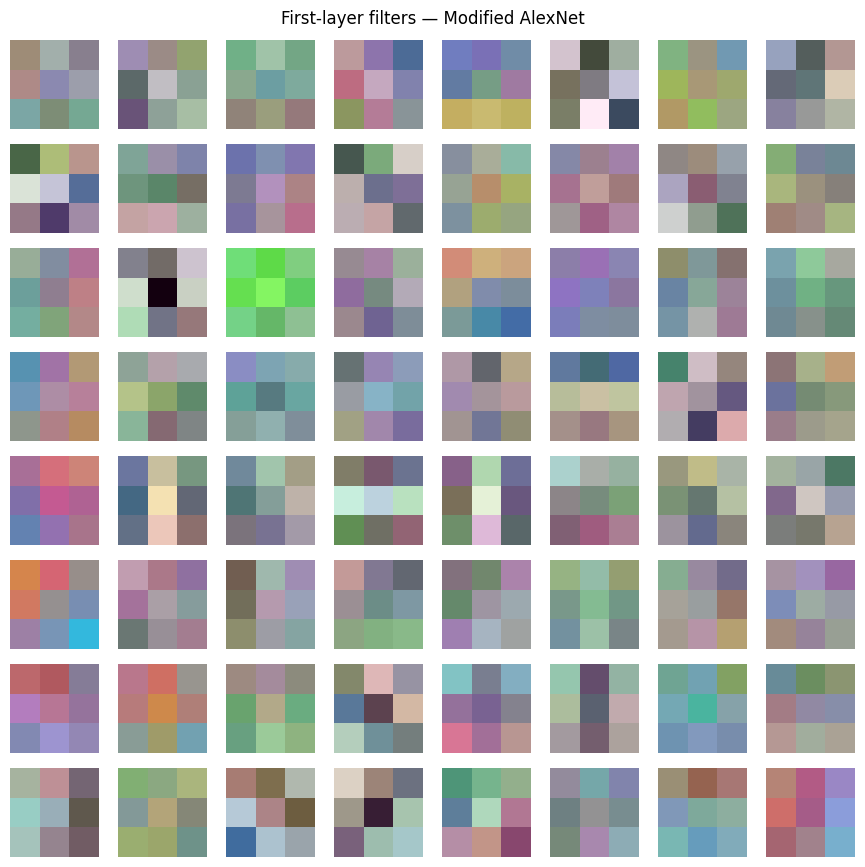

{
  "optimizer": "SGD",
  "lr": 0.01,
  "momentum": 0.9,
  "batch_size": 128,
  "epochs": 30,
  "scheduler": "none",
  "loss": "CrossEntropyLoss",
  "seed": 42
}
Test accuracy: 86.00%


In [ ]:
plot_history(['alexnet_baseline'], 'Modified AlexNet — baseline (Problem 1A)')
if alexnet_trained is None:
    alexnet_trained = load_weights(ModifiedAlexNet(), 'alexnet_baseline')
show_confusion(alexnet_trained, 'Modified AlexNet baseline')
show_first_layer_filters(alexnet_trained, 'Modified AlexNet')
print(json.dumps(RESULTS['alexnet_baseline']['hyperparams'], indent=2))
print(f"Test accuracy: {RESULTS['alexnet_baseline']['test_acc']*100:.2f}%")

In [ ]:
train_model(ModifiedAlexNet(dropout_p=0.3), 'alexnet_drop0.3', epochs=30)
train_model(ModifiedAlexNet(dropout_p=0.5), 'alexnet_drop0.5', epochs=30)

[alexnet_drop0.3] epoch   1/30 | train 2.2327 | val 1.9274 | val acc 26.88% | 18.9s
[alexnet_drop0.3] epoch   2/30 | train 1.8070 | val 1.6375 | val acc 38.28% | 19.5s
[alexnet_drop0.3] epoch   3/30 | train 1.5777 | val 1.4426 | val acc 46.90% | 18.7s
[alexnet_drop0.3] epoch   4/30 | train 1.3854 | val 1.2083 | val acc 56.58% | 19.7s
[alexnet_drop0.3] epoch   5/30 | train 1.2415 | val 1.0793 | val acc 61.62% | 18.6s
[alexnet_drop0.3] epoch   6/30 | train 1.1161 | val 1.0556 | val acc 61.82% | 19.2s
[alexnet_drop0.3] epoch   7/30 | train 0.9925 | val 0.8686 | val acc 68.78% | 18.9s
[alexnet_drop0.3] epoch   8/30 | train 0.9030 | val 0.8217 | val acc 70.10% | 19.0s
[alexnet_drop0.3] epoch   9/30 | train 0.8291 | val 0.8096 | val acc 71.74% | 18.8s
[alexnet_drop0.3] epoch  10/30 | train 0.7635 | val 0.7337 | val acc 73.28% | 18.6s
[alexnet_drop0.3] epoch  11/30 | train 0.7131 | val 0.6567 | val acc 76.42% | 19.6s
[alexnet_drop0.3] epoch  12/30 | train 0.6659 | val 0.7029 | val acc 75.42% 

ModifiedAlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=4096, out_features=1024, bias=True)
    

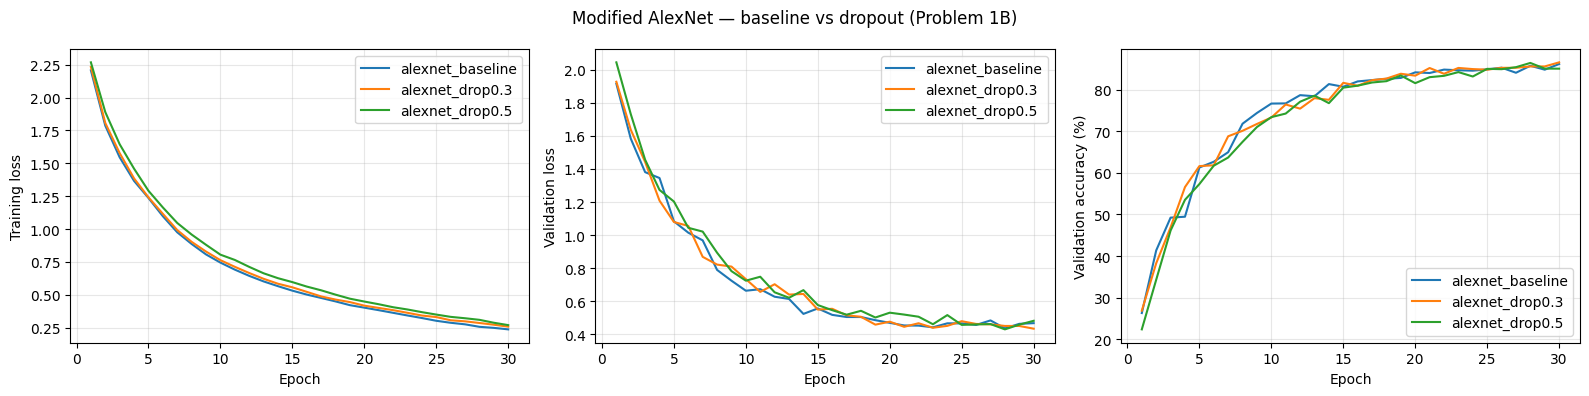

,model,params,test acc (%),best val acc (%),s / epoch,epochs to 70% val acc,final train-val gap (loss)
0,alexnet_baseline,"6,976,842",86.00,86.14,18.8,8,0.230
1,alexnet_drop0.3,"6,976,842",86.03,86.54,19.0,8,0.176
2,alexnet_drop0.5,"6,976,842",84.48,86.40,18.7,9,0.212


In [ ]:
alex_runs = ['alexnet_baseline', 'alexnet_drop0.3', 'alexnet_drop0.5']
plot_history(alex_runs, 'Modified AlexNet — baseline vs dropout (Problem 1B)')
comparison_table(alex_runs)

---
# Problem 2 — Adapted VGG-11

In [ ]:
VGG_CFGS = {
    'VGG-11': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'],
    'VGG-13': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'],
    'VGG-16': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M'],
    'VGG-19': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M'],
}

class VGGCifar(nn.Module):
    def __init__(self, cfg, num_classes=10, dropout_p=0.0):
        super().__init__()
        layers, in_ch = [], 3
        for v in cfg:
            if v == 'M':
                layers.append(nn.MaxPool2d(2))
            else:
                layers += [nn.Conv2d(in_ch, v, 3, padding=1), nn.ReLU(inplace=True)]
                in_ch = v
        self.features = nn.Sequential(*layers)          # output: 512 x 1 x 1
        def maybe_drop():
            return [nn.Dropout(dropout_p)] if dropout_p > 0 else []
        self.classifier = nn.Sequential(
            nn.Flatten(),
            *maybe_drop(), nn.Linear(512, 512), nn.ReLU(inplace=True),
            *maybe_drop(), nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

print(f"{'config':8s} {'adapted params':>16s} {'|diff vs AlexNet|':>20s}")
alex_params = count_params(ModifiedAlexNet())
for name, cfg in VGG_CFGS.items():
    p = count_params(VGGCifar(cfg))
    print(f'{name:8s} {p:>16,} {abs(p - alex_params):>20,}')
print(f'\nModified AlexNet: {alex_params:,}  ->  closest configuration: VGG-11')

config     adapted params    |diff vs AlexNet|
VGG-11          9,488,266            2,511,424
VGG-13          9,672,778            2,695,936
VGG-16         14,982,474            8,005,632
VGG-19         20,292,170           13,315,328

Modified AlexNet: 6,976,842  ->  closest configuration: VGG-11


In [ ]:
vgg = VGGCifar(VGG_CFGS['VGG-11'])
summary(vgg.to(device), (3, 32, 32))
vgg_trained = train_model(vgg, 'vgg11_baseline', epochs=30)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 128, 16, 16]          73,856
              ReLU-5          [-1, 128, 16, 16]               0
         MaxPool2d-6            [-1, 128, 8, 8]               0
            Conv2d-7            [-1, 256, 8, 8]         295,168
              ReLU-8            [-1, 256, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         590,080
             ReLU-10            [-1, 256, 8, 8]               0
        MaxPool2d-11            [-1, 256, 4, 4]               0
           Conv2d-12            [-1, 512, 4, 4]       1,180,160
             ReLU-13            [-1, 512, 4, 4]               0
           Conv2d-14            [-1, 51

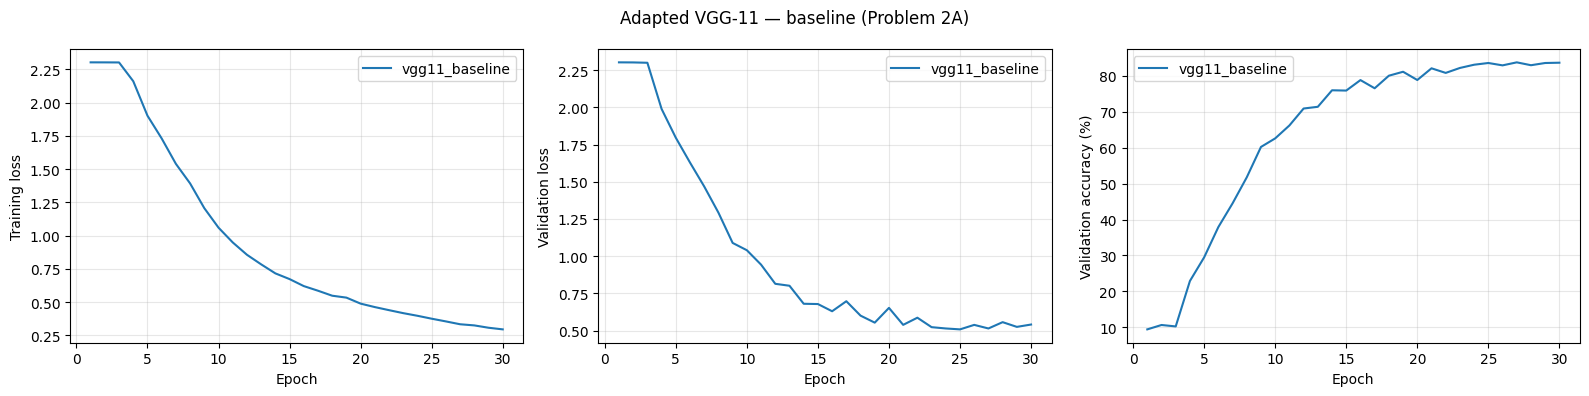

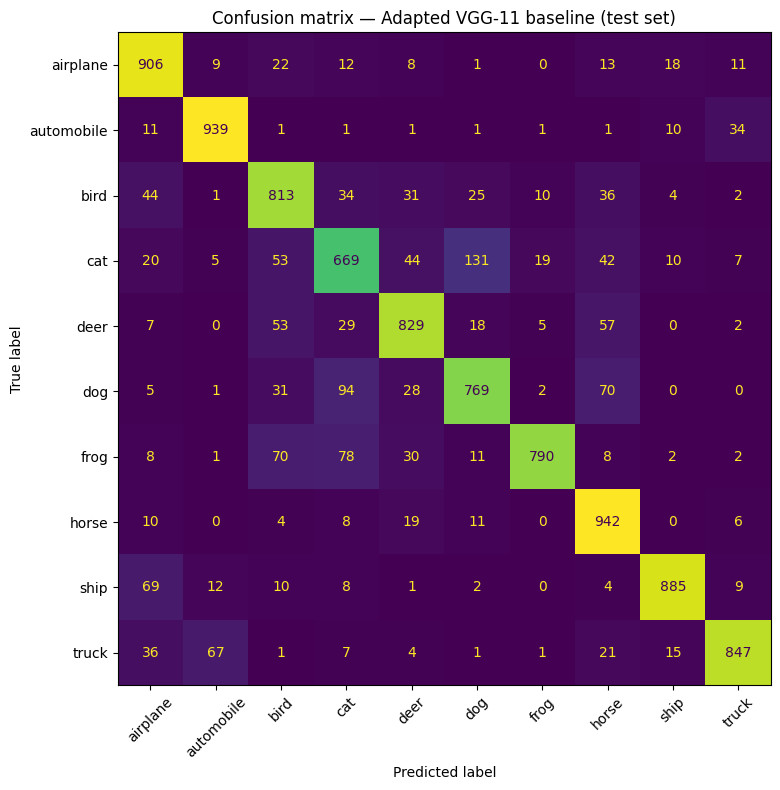

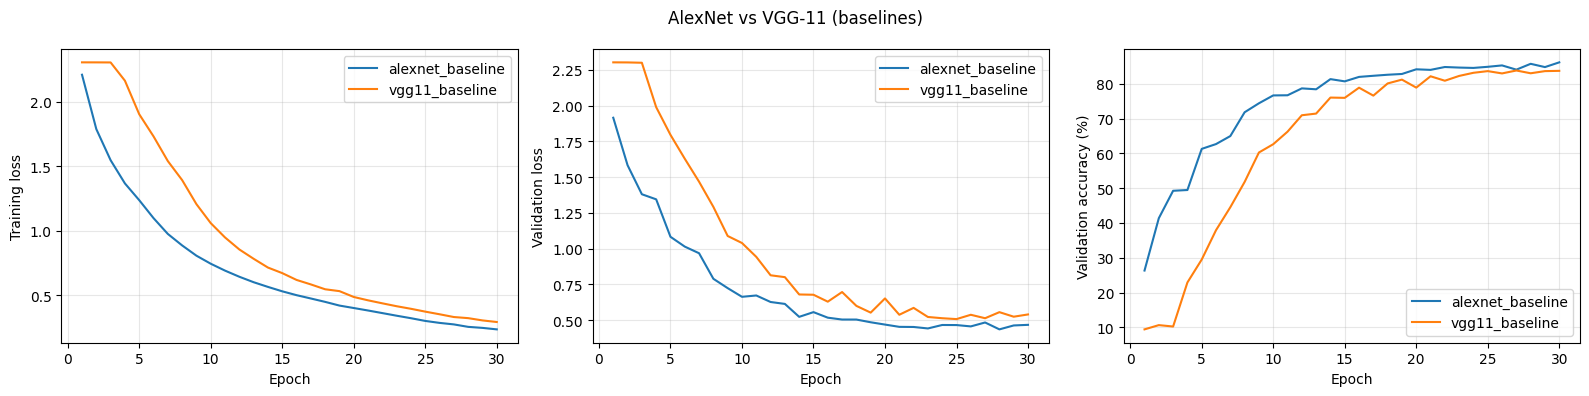

,model,params,test acc (%),best val acc (%),s / epoch,epochs to 70% val acc,final train-val gap (loss)
0,alexnet_baseline,"6,976,842",86.00,86.14,18.8,8,0.230
1,vgg11_baseline,"9,488,266",83.89,83.80,19.5,12,0.246


In [ ]:
plot_history(['vgg11_baseline'], 'Adapted VGG-11 — baseline (Problem 2A)')
if vgg_trained is None:
    vgg_trained = load_weights(VGGCifar(VGG_CFGS['VGG-11']), 'vgg11_baseline')
show_confusion(vgg_trained, 'Adapted VGG-11 baseline')

plot_history(['alexnet_baseline', 'vgg11_baseline'], 'AlexNet vs VGG-11 (baselines)')
comparison_table(['alexnet_baseline', 'vgg11_baseline'])

In [ ]:
train_model(VGGCifar(VGG_CFGS['VGG-11'], dropout_p=0.3), 'vgg11_drop0.3', epochs=30)
train_model(VGGCifar(VGG_CFGS['VGG-11'], dropout_p=0.5), 'vgg11_drop0.5', epochs=30)

[vgg11_drop0.3] epoch   1/30 | train 2.3029 | val 2.3027 | val acc 10.28% | 20.3s
[vgg11_drop0.3] epoch   2/30 | train 2.3028 | val 2.3032 | val acc 9.76% | 19.0s
[vgg11_drop0.3] epoch   3/30 | train 2.3026 | val 2.3020 | val acc 9.76% | 19.7s
[vgg11_drop0.3] epoch   4/30 | train 2.2735 | val 2.1303 | val acc 19.04% | 19.4s
[vgg11_drop0.3] epoch   5/30 | train 2.0042 | val 1.9179 | val acc 24.24% | 20.0s
[vgg11_drop0.3] epoch   6/30 | train 1.8452 | val 1.8044 | val acc 30.20% | 19.5s
[vgg11_drop0.3] epoch   7/30 | train 1.6990 | val 1.5984 | val acc 38.94% | 20.5s
[vgg11_drop0.3] epoch   8/30 | train 1.5487 | val 1.4202 | val acc 45.88% | 18.8s
[vgg11_drop0.3] epoch   9/30 | train 1.3638 | val 1.3169 | val acc 52.06% | 19.8s
[vgg11_drop0.3] epoch  10/30 | train 1.2011 | val 1.0563 | val acc 61.02% | 19.1s
[vgg11_drop0.3] epoch  11/30 | train 1.0518 | val 0.9512 | val acc 66.32% | 19.8s
[vgg11_drop0.3] epoch  12/30 | train 0.9479 | val 0.9342 | val acc 66.64% | 18.5s
[vgg11_drop0.3] ep

VGGCifar(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fal

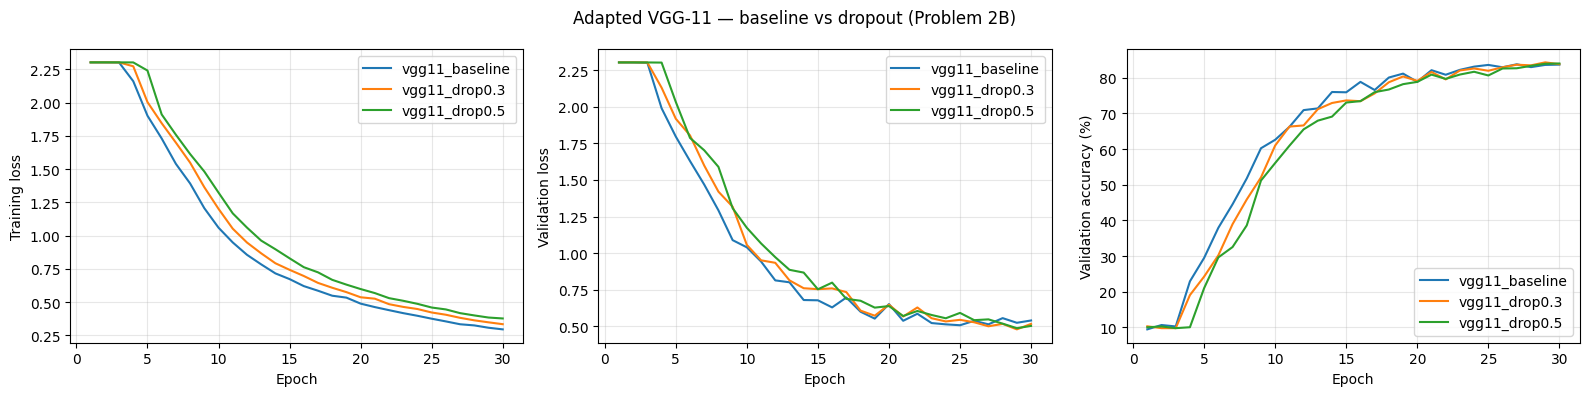

,model,params,test acc (%),best val acc (%),s / epoch,epochs to 70% val acc,final train-val gap (loss)
0,alexnet_baseline,"6,976,842",86.00,86.14,18.8,8,0.230
1,alexnet_drop0.3,"6,976,842",86.03,86.54,19.0,8,0.176
2,alexnet_drop0.5,"6,976,842",84.48,86.40,18.7,9,0.212
3,vgg11_baseline,"9,488,266",83.89,83.80,19.5,12,0.246
4,vgg11_drop0.3,"9,488,266",83.23,84.34,19.4,13,0.184
5,vgg11_drop0.5,"9,488,266",84.12,84.02,19.1,15,0.127


In [ ]:
vgg_runs = ['vgg11_baseline', 'vgg11_drop0.3', 'vgg11_drop0.5']
plot_history(vgg_runs, 'Adapted VGG-11 — baseline vs dropout (Problem 2B)')
comparison_table(['alexnet_baseline', 'alexnet_drop0.3', 'alexnet_drop0.5'] + vgg_runs)

---
# Problem 3 — ResNet-11 vs ResNet-18

In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:        # downsampling shortcut (1x1 conv + BN)
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)              # the skip connection
        return F.relu(out)

class ResNetCifar(nn.Module):
    def __init__(self, blocks_per_stage, num_classes=10, dropout_p=0.0):
        super().__init__()
        self.stem = nn.Sequential(                # CIFAR stem: 3x3 conv, stride 1, NO max pool
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        stages, in_ch = [], 64
        for i, (ch, n_blocks) in enumerate(zip([64, 128, 256, 512], blocks_per_stage)):
            for j in range(n_blocks):
                stride = 2 if (i > 0 and j == 0) else 1
                stages.append(BasicBlock(in_ch, ch, stride))
                in_ch = ch
        self.stages  = nn.Sequential(*stages)
        self.pool    = nn.AdaptiveAvgPool2d(1)    # global average pooling
        self.dropout = nn.Dropout(dropout_p) if dropout_p > 0 else nn.Identity()
        self.fc      = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stages(self.stem(x))
        x = self.pool(x).flatten(1)
        return self.fc(self.dropout(x))           # dropout sits after GAP (Part B)

def resnet18_cifar(dropout_p=0.0): return ResNetCifar([2, 2, 2, 2], dropout_p=dropout_p)
def resnet11_cifar(dropout_p=0.0): return ResNetCifar([2, 1, 1, 1], dropout_p=dropout_p)

print(f'ResNet-18 params: {count_params(resnet18_cifar()):,}')
print(f'ResNet-11 params: {count_params(resnet11_cifar()):,}')
summary(resnet18_cifar().to(device), (3, 32, 32))

ResNet-18 params: 11,173,962
ResNet-11 params: 4,977,226
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          36,864
       BatchNorm2d-5           [-1, 64, 32, 32]             128
            Conv2d-6           [-1, 64, 32, 32]          36,864
       BatchNorm2d-7           [-1, 64, 32, 32]             128
        BasicBlock-8           [-1, 64, 32, 32]               0
            Conv2d-9           [-1, 64, 32, 32]          36,864
      BatchNorm2d-10           [-1, 64, 32, 32]             128
           Conv2d-11           [-1, 64, 32, 32]          36,864
      BatchNorm2d-12           [-1, 64, 32, 32]             128
       BasicBlock-13           [-1, 64, 32, 32

In [ ]:
r18 = train_model(resnet18_cifar(), 'resnet18_baseline', epochs=50, lr=0.01, use_scheduler=True)
r11 = train_model(resnet11_cifar(), 'resnet11_baseline', epochs=50, lr=0.01, use_scheduler=True)

[resnet18_baseline] epoch   1/50 | train 1.4843 | val 1.4677 | val acc 50.28% | 43.2s
[resnet18_baseline] epoch   2/50 | train 0.9831 | val 1.0463 | val acc 65.00% | 40.0s
[resnet18_baseline] epoch   3/50 | train 0.7555 | val 0.6821 | val acc 76.70% | 40.5s
[resnet18_baseline] epoch   4/50 | train 0.6271 | val 0.7094 | val acc 76.22% | 39.8s
[resnet18_baseline] epoch   5/50 | train 0.5436 | val 0.5341 | val acc 81.50% | 40.0s
[resnet18_baseline] epoch   6/50 | train 0.4866 | val 0.5754 | val acc 80.64% | 40.2s
[resnet18_baseline] epoch   7/50 | train 0.4372 | val 0.4805 | val acc 83.42% | 40.0s
[resnet18_baseline] epoch   8/50 | train 0.3937 | val 0.4901 | val acc 83.20% | 39.8s
[resnet18_baseline] epoch   9/50 | train 0.3599 | val 0.4613 | val acc 84.08% | 40.1s
[resnet18_baseline] epoch  10/50 | train 0.3317 | val 0.4536 | val acc 84.36% | 40.6s
[resnet18_baseline] epoch  11/50 | train 0.3093 | val 0.4260 | val acc 86.64% | 39.8s
[resnet18_baseline] epoch  12/50 | train 0.2823 | val 

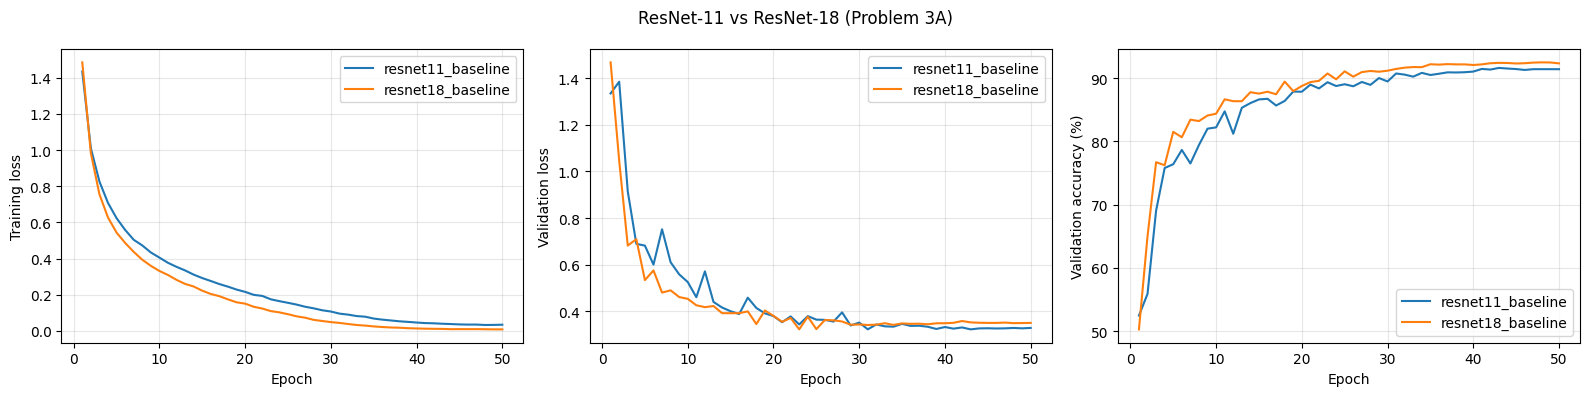

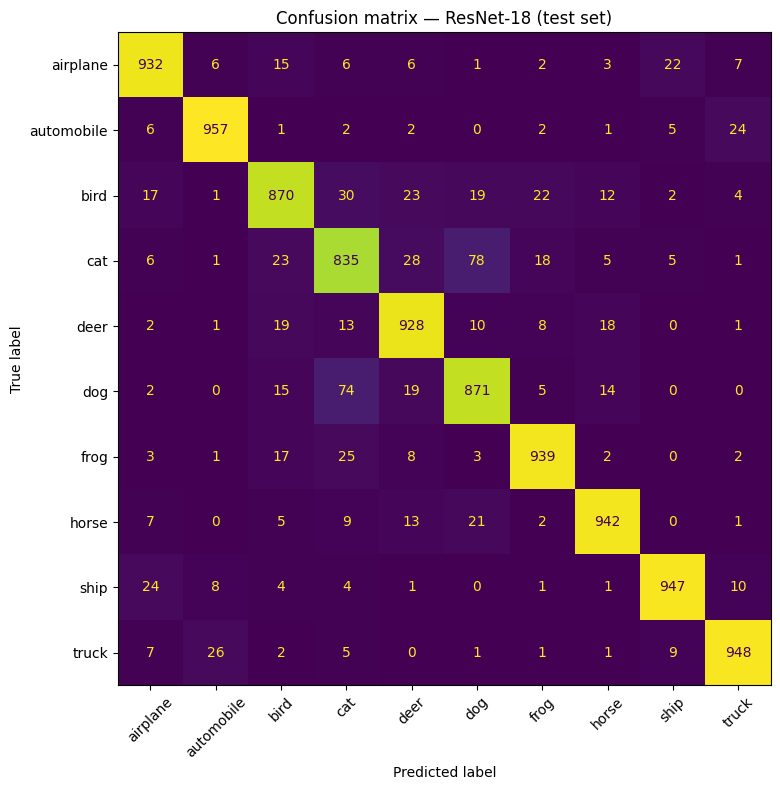

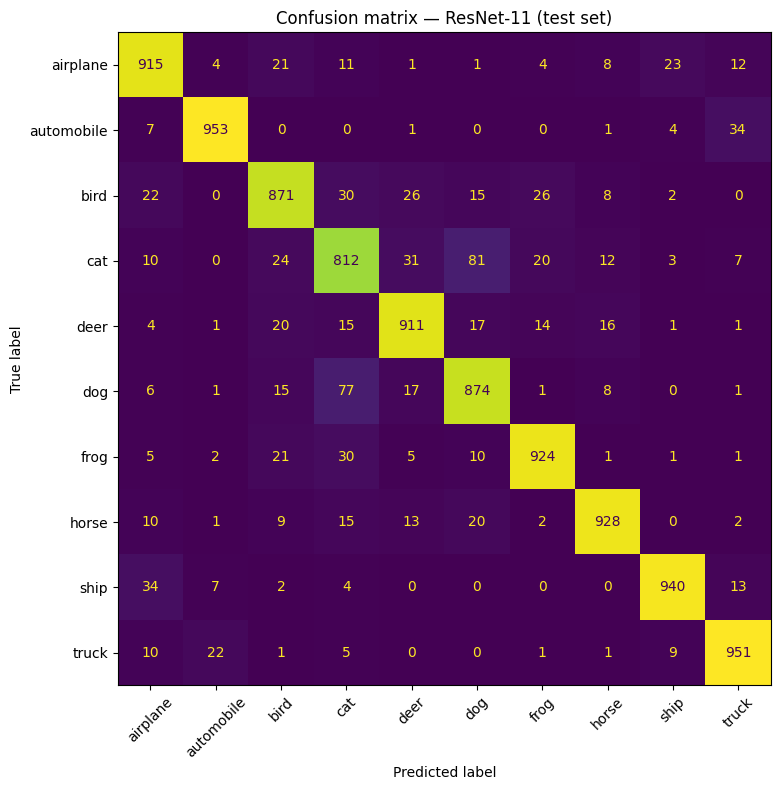

,model,params,test acc (%),best val acc (%),s / epoch,epochs to 70% val acc,final train-val gap (loss)
0,resnet11_baseline,"4,977,226",90.79,91.60,30.5,4,0.294
1,resnet18_baseline,"11,173,962",91.69,92.48,40.1,3,0.341


In [ ]:
plot_history(['resnet11_baseline', 'resnet18_baseline'], 'ResNet-11 vs ResNet-18 (Problem 3A)')
if r18 is None: r18 = load_weights(resnet18_cifar(), 'resnet18_baseline')
if r11 is None: r11 = load_weights(resnet11_cifar(), 'resnet11_baseline')
show_confusion(r18, 'ResNet-18')
show_confusion(r11, 'ResNet-11')
comparison_table(['resnet11_baseline', 'resnet18_baseline'])

In [ ]:
train_model(resnet11_cifar(dropout_p=0.3), 'resnet11_drop0.3', epochs=50, lr=0.01, use_scheduler=True)
train_model(resnet11_cifar(dropout_p=0.5), 'resnet11_drop0.5', epochs=50, lr=0.01, use_scheduler=True)
train_model(resnet18_cifar(dropout_p=0.3), 'resnet18_drop0.3', epochs=50, lr=0.01, use_scheduler=True)
train_model(resnet18_cifar(dropout_p=0.5), 'resnet18_drop0.5', epochs=50, lr=0.01, use_scheduler=True)

[resnet11_drop0.3] epoch   1/50 | train 1.4980 | val 1.5088 | val acc 48.86% | 31.9s
[resnet11_drop0.3] epoch   2/50 | train 1.0621 | val 1.1439 | val acc 61.02% | 30.9s
[resnet11_drop0.3] epoch   3/50 | train 0.8734 | val 1.0068 | val acc 66.82% | 30.3s
[resnet11_drop0.3] epoch   4/50 | train 0.7405 | val 0.7086 | val acc 75.58% | 30.4s
[resnet11_drop0.3] epoch   5/50 | train 0.6553 | val 0.7565 | val acc 75.02% | 30.9s
[resnet11_drop0.3] epoch   6/50 | train 0.6008 | val 0.6380 | val acc 77.50% | 30.5s
[resnet11_drop0.3] epoch   7/50 | train 0.5452 | val 0.6191 | val acc 79.44% | 30.3s
[resnet11_drop0.3] epoch   8/50 | train 0.5002 | val 0.5934 | val acc 80.50% | 31.1s
[resnet11_drop0.3] epoch   9/50 | train 0.4644 | val 0.6434 | val acc 78.84% | 30.3s
[resnet11_drop0.3] epoch  10/50 | train 0.4368 | val 0.4591 | val acc 84.26% | 30.2s
[resnet11_drop0.3] epoch  11/50 | train 0.4090 | val 0.5688 | val acc 81.90% | 31.0s
[resnet11_drop0.3] epoch  12/50 | train 0.3791 | val 0.5227 | val

ResNetCifar(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (stages): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    

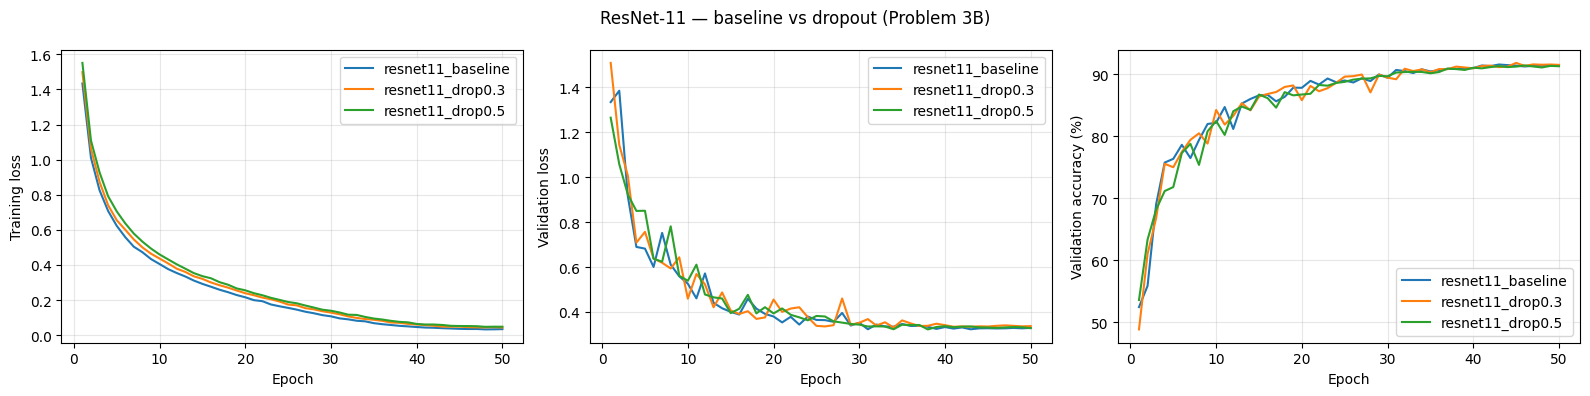

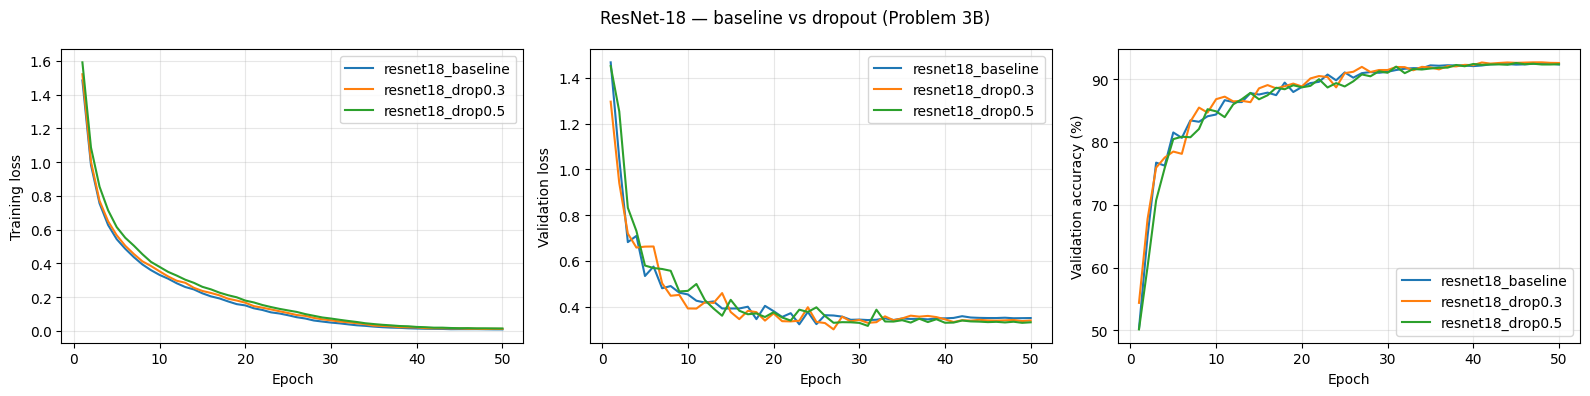

,model,params,test acc (%),best val acc (%),s / epoch,epochs to 70% val acc,final train-val gap (loss)
0,resnet11_baseline,"4,977,226",90.79,91.60,30.5,4,0.294
1,resnet11_drop0.3,"4,977,226",91.08,91.86,30.5,4,0.293
2,resnet11_drop0.5,"4,977,226",90.76,91.44,30.5,4,0.279
3,resnet18_baseline,"11,173,962",91.69,92.48,40.1,3,0.341
4,resnet18_drop0.3,"11,173,962",91.81,92.66,40.1,3,0.328
5,resnet18_drop0.5,"11,173,962",91.88,92.56,40.1,3,0.317


In [ ]:
plot_history(['resnet11_baseline', 'resnet11_drop0.3', 'resnet11_drop0.5'],
             'ResNet-11 — baseline vs dropout (Problem 3B)')
plot_history(['resnet18_baseline', 'resnet18_drop0.3', 'resnet18_drop0.5'],
             'ResNet-18 — baseline vs dropout (Problem 3B)')
comparison_table(['resnet11_baseline', 'resnet11_drop0.3', 'resnet11_drop0.5',
                  'resnet18_baseline', 'resnet18_drop0.3', 'resnet18_drop0.5'])

---
# Final comparison

   family     best variant     params  test acc (%)  total training time (min)
  AlexNet  alexnet_drop0.3  6,976,842         86.03                        9.5
   VGG-11    vgg11_drop0.5  9,488,266         84.12                        9.5
ResNet-11 resnet11_drop0.3  4,977,226         91.08                       25.4
ResNet-18 resnet18_drop0.5 11,173,962         91.88                       33.5


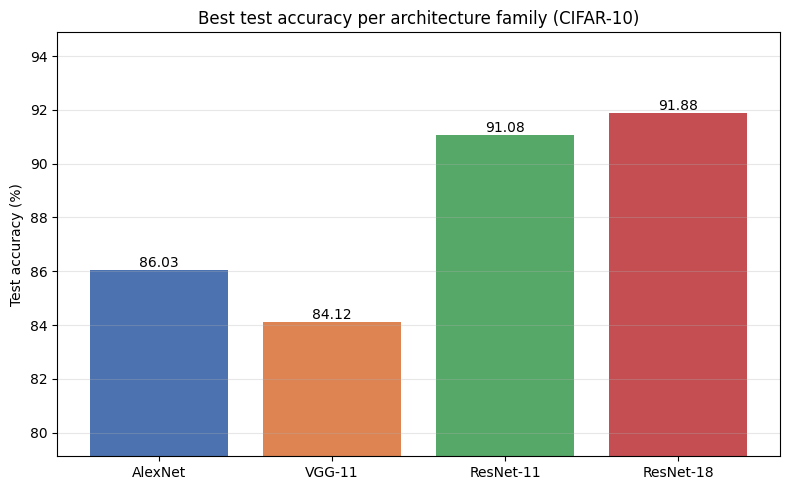

In [ ]:
FAMILIES = {
    'AlexNet':   ['alexnet_baseline', 'alexnet_drop0.3', 'alexnet_drop0.5'],
    'VGG-11':    ['vgg11_baseline', 'vgg11_drop0.3', 'vgg11_drop0.5'],
    'ResNet-11': ['resnet11_baseline', 'resnet11_drop0.3', 'resnet11_drop0.5'],
    'ResNet-18': ['resnet18_baseline', 'resnet18_drop0.3', 'resnet18_drop0.5'],
}

best = {}
for fam, runs in FAMILIES.items():
    done = [r for r in runs if r in RESULTS]
    best[fam] = max(done, key=lambda r: RESULTS[r]['test_acc'])

rows = []
for fam, run in best.items():
    r = RESULTS[run]
    total_min = sum(r['history']['epoch_time']) / 60
    rows.append({'family': fam, 'best variant': run,
                 'params': f"{r['params']:,}",
                 'test acc (%)': round(r['test_acc'] * 100, 2),
                 'total training time (min)': round(total_min, 1)})
final_df = pd.DataFrame(rows)
print(final_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
accs = [RESULTS[run]['test_acc'] * 100 for run in best.values()]
bars = ax.bar(list(best.keys()), accs, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
ax.bar_label(bars, fmt='%.2f')
ax.set_ylabel('Test accuracy (%)')
ax.set_ylim(min(accs) - 5, max(accs) + 3)
ax.set_title('Best test accuracy per architecture family (CIFAR-10)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()